## Load and parse the OpenSim '.sto' file


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

DATA_DIR = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/fixed_elbowtest"
SAVE_DIR = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/fixed_elbowtest"

def load_sto(path):
    """Parse an OpenSim .sto file into a pandas DataFrame."""
    with open(path) as f:
        lines = f.readlines()
    header_end = next(i for i, l in enumerate(lines) if l.strip() == "endheader")
    df = pd.read_csv(path, sep="\t", skiprows=header_end + 1)
    df.columns = [c.strip() for c in df.columns]
    return df

bk = load_sto(os.path.join(DATA_DIR, "Right_BodyKinematics_pos_global.sto"))
bk.head()

,time,clavicle_X,clavicle_Y,clavicle_Z,clavicle_Ox,clavicle_Oy,clavicle_Oz,clavphant_X,clavphant_Y,clavphant_Z,...,proximal_row_Oz,hand_X,hand_Y,hand_Z,hand_Ox,hand_Oy,hand_Oz,center_of_mass_X,center_of_mass_Y,center_of_mass_Z
0,0.000000,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,48.790382,0.230877,-0.206461,0.595708,-69.780308,20.256273,48.790382,0.030883,-0.086356,0.350865
1,0.015152,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,49.469740,0.232947,-0.206353,0.592613,-69.776930,20.298072,49.469740,0.031331,-0.086322,0.350160
2,0.030303,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,50.149278,0.234983,-0.206226,0.589496,-69.774079,20.339905,50.149279,0.031771,-0.086284,0.349452
3,0.045455,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,50.828999,0.236985,-0.206079,0.586359,-69.771758,20.381767,50.828999,0.032203,-0.086242,0.348739
4,0.060606,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,51.508903,0.238954,-0.205913,0.583200,-69.769965,20.423652,51.508903,0.032628,-0.086195,0.348021


## Extract shoulder / elbow / wrist (end effector) positions
`humerus_X/Y/Z` = shoulder proxy, `ulna_X/Y/Z` = elbow proxy, `hand_X/Y/Z` = wrist (end effector). Positions are in meters (S.I. units); centered on the shoulder and converted to cm to match the paper's axis convention.

In [10]:
time = bk["time"].to_numpy()

shoulder = bk[["humerus_X", "humerus_Y", "humerus_Z"]].to_numpy()
elbow    = bk[["ulna_X",    "ulna_Y",    "ulna_Z"]].to_numpy()
wrist    = bk[["hand_X",    "hand_Y",    "hand_Z"]].to_numpy()  # end effector

# Center relative to shoulder, matching Ef3D dataset convention; convert m -> cm
elbow_endeffector_coords = (elbow - shoulder) * 100
endeffector_coords = (wrist - shoulder) * 100
shoulder_coords = np.array([[0], [0], [0]])
elbow_coords = elbow_endeffector_coords.T

## Elbow sweep example 

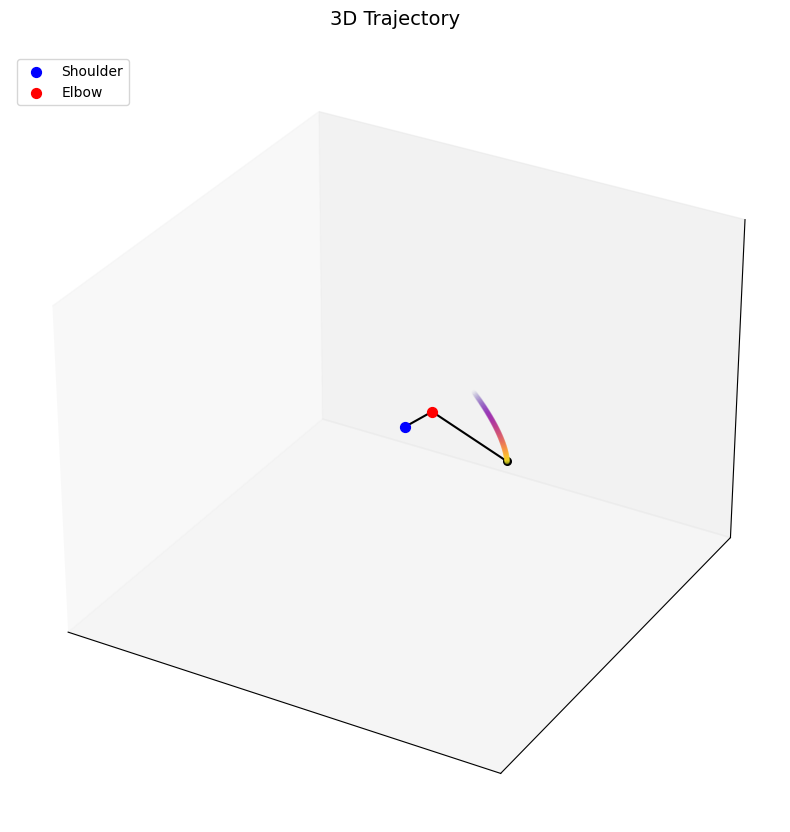

In [11]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2)

x_min = -50
x_max = 50
y_min = -50
y_max = 50
z_min = -50
z_max = 50

cmap = plt.cm.plasma  # You can choose any colormap
norm = Normalize(vmin=0, vmax=len(time))

# Generate alpha values increasing from 0 to 1
alpha_values = np.linspace(0, 1, len(time))

# Map indices to colors in the colormap
colors = [cmap(norm(i)) for i in range(len(time))]

# Adjust alpha of each color
colors_with_alpha = [(r, g, b, alpha) for (r, g, b, _), alpha in zip(colors, alpha_values)]

endeffector_coords_T = endeffector_coords.T  # shape (3, T) to match paper convention

ax = fig.add_subplot(111, projection="3d")
ax.scatter(endeffector_coords_T[0, :], endeffector_coords_T[1, :], endeffector_coords_T[2, :], c=colors_with_alpha, s=10)
ax.scatter(endeffector_coords_T[0, -1], endeffector_coords_T[1, -1], endeffector_coords_T[2, -1], c='black', s=30)

ax.scatter(0, 0, 0, c='blue', s=50, label='Shoulder')

ax.scatter(elbow_coords[0, -1], elbow_coords[1, -1], elbow_coords[2, -1], c='red', s=50, label='Elbow')

# Connect the shoulder and elbow
ax.plot([shoulder_coords[0, -1], elbow_coords[0, -1]], [shoulder_coords[1, -1], elbow_coords[1, -1]], [shoulder_coords[2, -1], elbow_coords[2, -1]], c='black')
# Connect the elbow and endeffector
ax.plot([elbow_coords[0, -1], endeffector_coords_T[0, -1]], [elbow_coords[1, -1], endeffector_coords_T[1, -1]], [elbow_coords[2, -1], endeffector_coords_T[2, -1]], c='black')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

ax.set_title("Endeffector coordinates")

# Add grid lines for better readability
ax.grid(True, linestyle=".", alpha=1)

# Add a title and a legend
ax.set_title("3D Trajectory", fontsize=14, pad=20)
ax.legend(loc="upper left", fontsize=10)

# Reduce clutter by hiding pane spines
ax.xaxis.pane.fill = True
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.savefig(os.path.join(SAVE_DIR, "elbow_sweep_trajectory.png"), dpi=150)
plt.show()

## Sanity check
Confirms the sweep matches what was generated (45deg -> 90deg elbow flexion, shoulder held fixed) and that the wrist path extent looks anatomically reasonable.

In [12]:
q = load_sto(os.path.join(DATA_DIR, "Right_Kinematics_q.sto"))
print("elbow_flexion: {:.2f} -> {:.2f} deg".format(q["elbow_flexion"].iloc[0], q["elbow_flexion"].iloc[-1]))
print("shoulder_elv: {:.2f} -> {:.2f} deg".format(q["shoulder_elv"].iloc[0], q["shoulder_elv"].iloc[-1]))
print("shoulder_rot: {:.2f} -> {:.2f} deg".format(q["shoulder_rot"].iloc[0], q["shoulder_rot"].iloc[-1]))
print()
print("Wrist path extent (cm), min:", endeffector_coords_T.min(axis=1))
print("Wrist path extent (cm), max:", endeffector_coords_T.max(axis=1))

elbow_flexion: 45.00 -> 90.00 deg
shoulder_elv: 70.00 -> 70.00 deg
shoulder_rot: 20.00 -> 20.00 deg

Wrist path extent (cm), min: [ 24.698723 -15.357936   7.829974]
Wrist path extent (cm), max: [ 30.51839  -10.751623  30.686057]
